In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets,transforms
import matplotlib.pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

batch_size=512
device=torch.device('cuda'if torch.cuda.is_available() else 'cpu')
trainloader = torch.utils.data.DataLoader(datasets.MNIST('data',train=True,download=True,
                                                         transform=transforms.Compose([transforms.ToTensor()])),batch_size=batch_size,shuffle=True)
testloader = torch.utils.data.DataLoader(datasets.MNIST('data',train=False,download=True,
                                                         transform=transforms.Compose([transforms.ToTensor()])),batch_size=batch_size,shuffle=True)

class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        self.conv1=nn.Conv2d(in_channels=1,out_channels=6,kernel_size=5,padding=2)
        self.conv2=nn.Conv2d(in_channels=6,out_channels=16,kernel_size=5)
        self.fc1=nn.Linear(5*5*16,120)
        self.fc2=nn.Linear(120,84)
        self.clf=nn.Linear(84,10)
        self.relu=nn.Sigmoid()
        self.pool=nn.AvgPool2d(kernel_size=2,stride=2)
        self.flatten=nn.Flatten(start_dim=1)
    
    def forward(self,x):
        x=self.conv1(x)
        x=self.relu(x)
        x=self.pool(x)

        x=self.conv2(x)
        x=self.relu(x)
        x=self.pool(x)

        x=self.flatten(x)
        x=self.fc1(x)
        x=self.relu(x)

        x=self.fc2(x)
        x=self.relu(x)

        x=self.clf(x)
        return x
    
model=Net().to(device)
optimizer=optim.Adam(model.parameters(),lr=1e-2)

In [8]:
epochs=30
accs,losses=[],[]
for epoch in range(epochs):
    for batch_idx,(x,y) in enumerate(trainloader):
        x,y=x.to(device),y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = F.cross_entropy(out,y)
        loss.backward()
        optimizer.step()
    
    correct=0
    testloss=0
    with torch.no_grad():
        for batch_idx,(x,y) in enumerate(testloader):
            x,y=x.to(device),y.to(device)
            out=model(x)
            testloss +=F.cross_entropy(out,y).item()
            pred=out.max(dim=1,keepdim=True)[1]
            correct +=pred.eq(y.view_as(pred)).sum().item()

    acc = correct/len(testloader.dataset)
    testloss = testloss/(batch_idx+1)
    accs.append(acc)
    losses.append(testloss)
    print('epoch:{},loss:{:4f},acc:{:4f}'.format(epoch,testloss,acc))

epoch:0,loss:2.301466,acc:0.113500
epoch:1,loss:2.301534,acc:0.113500
epoch:2,loss:2.301126,acc:0.113500
epoch:3,loss:2.301366,acc:0.113500
epoch:4,loss:2.300994,acc:0.113500
epoch:5,loss:2.095140,acc:0.225700
epoch:6,loss:0.536351,acc:0.821200
epoch:7,loss:0.176625,acc:0.946100
epoch:8,loss:0.112669,acc:0.963600
epoch:9,loss:0.088730,acc:0.971800
epoch:10,loss:0.074218,acc:0.975500
epoch:11,loss:0.079109,acc:0.976900
epoch:12,loss:0.051346,acc:0.983600
epoch:13,loss:0.053315,acc:0.983100
epoch:14,loss:0.045855,acc:0.985700
epoch:15,loss:0.037608,acc:0.988000
epoch:16,loss:0.039594,acc:0.988200
epoch:17,loss:0.041099,acc:0.987100
epoch:18,loss:0.037346,acc:0.988700
epoch:19,loss:0.037215,acc:0.989100
epoch:20,loss:0.037987,acc:0.988900
epoch:21,loss:0.031769,acc:0.989700
epoch:22,loss:0.035217,acc:0.989900
epoch:23,loss:0.044597,acc:0.987500
epoch:24,loss:0.036204,acc:0.989200
epoch:25,loss:0.033249,acc:0.988900
epoch:26,loss:0.039878,acc:0.988200
epoch:27,loss:0.039106,acc:0.988600
ep

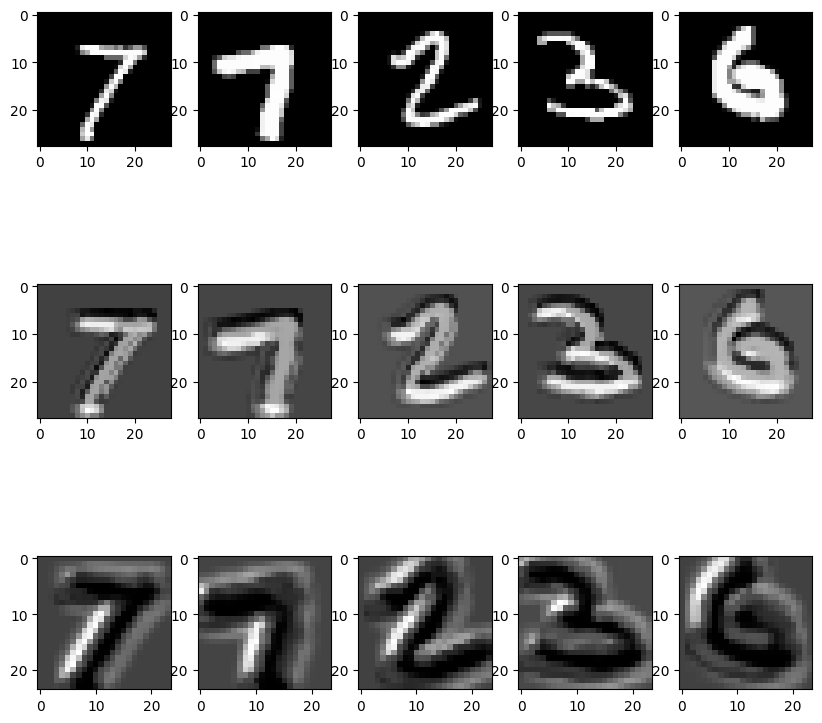

In [10]:
feature1=F.sigmoid(model.conv1(x))
feature2=F.sigmoid(model.conv2(feature1))
n=5
img = x.detach().cpu().numpy()[:n]
feature_map1=feature1.detach().cpu().numpy()[:n]
feature_map2=feature2.detach().cpu().numpy()[:n]
# x.detach() - 从计算图中分离，不跟踪梯度
# .cpu() - 从GPU移到CPU（如果用了GPU）
# .numpy() - 转成numpy数组，便于matplotlib显示
# [:n] - 只取前n个样本
# 结果：原始输入图像的numpy数组

fig,ax=plt.subplots(3,n,figsize=(10,10))
for i in range(n):
    ax[0,i].imshow(img[i].sum(0),cmap='gray')
    ax[1,i].imshow(feature_map1[i].sum(0),cmap='gray')
    ax[2,i].imshow(feature_map2[i].sum(0),cmap='gray')
plt.show()

In [11]:
import numpy as np
import cv2
from PIL import Image

In [14]:
def preprocess_image(image):
    """预处理手写数字图像"""
    # 转换为灰度图 - 如果输入是彩色图像(3通道)，转换为单通道灰度图
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # 调整大小为28x28 - MNIST数据集的标准输入尺寸
    image = cv2.resize(image, (28, 28))
    
    # 反转颜色（MNIST是白底黑字，我们绘制的是黑底白字）
    # 因为我们是在白色画布上画黑色数字，而MNIST是黑色背景白色数字
    image = 255 - image
    
    # 归一化并转换为tensor - 将像素值从0-255缩放到0-1之间
    image = image.astype(np.float32) / 255.0
    # 添加batch和channel维度: (28,28) -> (1,1,28,28)
    image = torch.from_numpy(image).unsqueeze(0).unsqueeze(0)  
    return image.to(device)  # 移动到GPU或CPU设备

def draw_digit():
    """绘制数字并识别"""
    # 创建画布 - 280x280的白色画布（255表示白色）
    canvas = np.ones((280, 280), dtype=np.uint8) * 255
    drawing = False  # 标记是否正在绘制
    
    def draw_circle(event, x, y, flags, param):
        nonlocal drawing, canvas
        if event == cv2.EVENT_LBUTTONDOWN:  # 鼠标左键按下
            drawing = True
        elif event == cv2.EVENT_MOUSEMOVE:  # 鼠标移动
            if drawing:
                # 在鼠标位置画一个实心圆，颜色为黑色(0)，半径15像素
                cv2.circle(canvas, (x, y), 15, 0, -1)
        elif event == cv2.EVENT_LBUTTONUP:  # 鼠标左键释放
            drawing = False
    
    # 创建绘制窗口并设置鼠标回调函数
    cv2.namedWindow('Draw Digit')
    cv2.setMouseCallback('Draw Digit', draw_circle)
    
    print("请在窗口中绘制数字，按's'识别，按'c'清除，按'q'退出")
    
    while True:
        # 显示绘制窗口
        cv2.imshow('Draw Digit', canvas)
        key = cv2.waitKey(1) & 0xFF  # 等待键盘输入
        
        if key == ord('s'):  # 按's'键进行识别
            # 预处理图像 - 将绘制的图像转换为模型可接受的格式
            processed_img = preprocess_image(canvas)
            
            # 使用训练好的模型进行预测
            with torch.no_grad():  # 不计算梯度，节省内存
                output = model(processed_img)  # 模型前向传播
                prediction = torch.argmax(output, dim=1).item()  # 获取预测结果（最大概率的类别）
                probabilities = F.softmax(output, dim=1)[0]  # 计算每个类别的概率
    
            # 显示结果 - 在原画布上添加识别结果文字
            result_canvas = canvas.copy()
            # 在画布上显示预测结果
            cv2.putText(result_canvas, f'Prediction: {prediction}', (10, 30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, 0, 2)  # 字体、大小、颜色、粗细
            # 在画布上显示置信度
            cv2.putText(result_canvas, f'Confidence: {probabilities[prediction]:.2f}', (10, 70), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, 0, 2)
            cv2.imshow('Result', result_canvas)  # 显示结果窗口
            
            # 在控制台打印识别结果
            print(f"识别结果: {prediction}, 置信度: {probabilities[prediction]:.4f}")
            
        elif key == ord('c'):  # 按'c'键清除画布
            canvas = np.ones((280, 280), dtype=np.uint8) * 255  # 重新创建白色画布
            
        elif key == ord('q'):  # 按'q'键退出程序
            break
    
    # 关闭所有OpenCV窗口
    cv2.destroyAllWindows()

# 启动交互式识别
print("开始交互式数字识别...")
draw_digit()

开始交互式数字识别...
请在窗口中绘制数字，按's'识别，按'c'清除，按'q'退出
识别结果: 1, 置信度: 0.5948
识别结果: 2, 置信度: 1.0000
识别结果: 5, 置信度: 1.0000
识别结果: 5, 置信度: 0.5076
识别结果: 6, 置信度: 0.9999
识别结果: 1, 置信度: 1.0000
识别结果: 4, 置信度: 1.0000
识别结果: 0, 置信度: 0.9567
识别结果: 0, 置信度: 0.9192
